In [3]:
import numpy as np
import pandas as pd
import os
from scipy.stats import expon, uniform, beta

from tqdm import tqdm
from joblib import cpu_count
import networkx as nx
import pickle
import matplotlib.pyplot as plt
from collections import Counter

from InfluenceDiffusion.estimation_models.OptimEstimation import GLTWeightEstimator, GLTWeightDistribEstimator
from InfluenceDiffusion.weight_samplers import make_random_weights_with_indeg_constraint, make_weighted_cascade_weights
from InfluenceDiffusion.influence_models import LTM, GLTM
from InfluenceDiffusion.Graph import Graph
from InfluenceDiffusion.Trace import Trace, Traces

os.chdir("/Users/amkagan/Desktop/Archive/gltm_experiments")
from utils.trace_utils import trace_train_test_split, compute_vertex_sample_size
from utils.utils import RMAE

print("CPUs available", cpu_count())

CPUs available 10


In [4]:
n_nodes = 100
init_k = 10
rewire_p = 0.2
n_traces = 2000

random_state = 1
max_seed_size = 10
seed_size_range = list(range(1, max_seed_size + 1))


n_traces = 2000

max_alternate_iter = 50
tol = 0


In [6]:
g = nx.watts_strogatz_graph(n_nodes, k=init_k, p=rewire_p, seed=random_state)
g = Graph(g.edges)

weights = make_random_weights_with_indeg_constraint(g, indeg_ub=1, random_state=random_state)                       
g.set_weights(weights)

# Counter(g.get_all_indegrees())

In [ ]:
np.random.seed(random_state)
max_ab = 5
true_as = np.random.randint(1, max_ab + 1, size=n_nodes)
true_bs = np.random.randint(1, max_ab + 1, size=n_nodes)
vertex_2_threshold_generator = {v: beta(a, b) for v, (a, b) in enumerate(zip(true_as, true_bs))}

gltm = GLTM(g, threshold_distribs=vertex_2_threshold_generator, random_state=random_state)
traces = gltm.sample_traces(n_traces, seed_size_range=seed_size_range)

## Stability to weight initialization

In [ ]:
gltm_estim_ab_oracle = GLTWeightDistribEstimator(g, distrib_family=beta, 
                                                 distrib_params_2_range={"a": (1, 5), "b": (1, 5)})

# golden standard is estimator initialized with true weights
gltm_estim_ab_oracle.fit(traces, init_weights=g.weights, max_alternate_iter=max_alternate_iter, tol=0)

In [ ]:
n_inits = 10
rs_range = range(random_state + 1, random_state + n_inits + 1)
vertex_param_histories_over_rs = []
vertex_weight_histories_over_rs = []
vertex_nll_histories_over_rs = []

gltm_estim_ab = GLTWeightDistribEstimator(g, distrib_family=beta, 
                                          distrib_params_2_range={"a": (1, 5), "b": (1, 5)})

for rs in tqdm(rs_range):
    init_weights = make_random_weights_with_indeg_constraint(g, indeg_ub=1, random_state=rs)
    gltm_estim_ab.fit(traces, init_weights=init_weights, max_alternate_iter=max_alternate_iter, tol=tol)
    vertex_param_histories_over_rs.append(gltm_estim_ab.distrib_param_history_)
    vertex_weight_histories_over_rs.append(gltm_estim_ab.weights_history_)
    vertex_nll_histories_over_rs.append(gltm_estim_ab.nll_history_)

In [123]:
def plot_convergence(
    true_values,
    pred_values,
    xlab="Alternating iteration",
    ylab="Relative MAE",
    metric=RMAE,
    n_std=2,
    ax=None,
    fontsize=12,
    marker=None
):
    """
    Plot mean error with confidence bounds across iterations.

    Parameters
    ----------
    true_values : array-like of shape (n_features,)
        Ground-truth values.

    pred_values : array-like of shape
        (n_replications, n_iterations, n_features)
        Predicted values across replications and iterations.

    metric : callable
        Metric supporting an ``axis`` argument, such as RMAE.

    n_std : float
        Number of standard deviations used for the bounds.

    ax : matplotlib.axes.Axes, optional
        Axes on which to draw the plot.

    fontsize : int, optional
        Font size for axis labels and ticks.

    marker : str, optional
        Marker style for the mean error line.

    Returns
    -------
    matplotlib.axes.Axes
    """
    true_values = np.asarray(true_values)
    pred_values = np.asarray(pred_values)

    if true_values.ndim != 1:
        raise ValueError(
            "true_values must have shape (n_features,)."
        )

    if pred_values.ndim != 3:
        raise ValueError(
            "pred_values must have shape "
            "(n_replications, n_iterations, n_features)."
        )

    if pred_values.shape[2] != true_values.shape[0]:
        raise ValueError(
            "The n_features dimension of pred_values must match "
            "the length of true_values."
        )

    # Shape: (n_replications, n_iterations)
    errors = np.apply_along_axis(
        lambda y_pred: metric(true_values, y_pred),
        axis=-1,
        arr=pred_values,
    )

    # Aggregate across replications.
    mean_error = np.mean(errors, axis=0)
    std_error = np.std(errors, axis=0)

    lower = mean_error - n_std * std_error
    upper = mean_error + n_std * std_error

    iterations = np.arange(1, pred_values.shape[1] + 1)

    if ax is None:
        _, ax = plt.subplots()

    ax.plot(iterations, mean_error, marker=marker, linewidth=2.5)
    ax.plot(iterations, lower, linewidth=1.5, linestyle="--", color=ax.lines[-1].get_color())
    ax.plot(iterations, upper, linewidth=1.5, linestyle="--", color=ax.lines[-1].get_color())
    ax.fill_between(iterations, lower, upper, alpha=0.25)

    ax.set_xlabel(xlab, fontsize=fontsize)
    ax.set_ylabel(ylab, fontsize=fontsize)
    ax.tick_params(axis='both', which='major', labelsize=fontsize)

    return ax

In [109]:
fitted_params_df = pd.DataFrame(gltm_estim_ab_oracle.get_fitted_threshold_distrib_params()).T
filter_cond = lambda v: g.get_indegree(v) >= 3

node_sample = [v for v in gltm_estim_ab_oracle.informative_vertices if filter_cond(v)]

# fitted_params_df.loc[node_sample].boxplot(figsize=(6, 4))

In [124]:
oracle_pred_weights = np.hstack([gltm_estim_ab_oracle.weights_[g.get_parents_mask(v)] for v in node_sample])
oracle_pred_distrib_params = gltm_estim_ab_oracle.get_fitted_threshold_distrib_params()
oracle_pred_as = np.hstack([oracle_pred_distrib_params[v]["a"] for v in node_sample])  
oracle_pred_bs = np.hstack([oracle_pred_distrib_params[v]["b"] for v in node_sample])  

In [125]:
true_sample_weights = np.hstack([g.weights[g.get_parents_mask(v)] for v in node_sample])
true_sample_as = np.hstack([true_as[v] for v in node_sample])
true_sample_bs = np.hstack([true_bs[v] for v in node_sample])

RMAE(true_sample_weights, oracle_pred_weights), RMAE(true_sample_as, oracle_pred_as), RMAE(true_sample_bs, oracle_pred_bs)

(np.float64(0.0975159648143652),
 np.float64(0.08331792515390166),
 np.float64(0.10088986077075619))

In [126]:
a_histories_over_rs = [[np.hstack([param_hists_over_vertices[v][iteration][0] for v in node_sample])
                        for iteration in range(max_alternate_iter)] 
                       for param_hists_over_vertices in vertex_param_histories_over_rs]
b_histories_over_rs = [[np.hstack([param_hists_over_vertices[v][iteration][1] for v in node_sample])
                        for iteration in range(max_alternate_iter)] 
                       for param_hists_over_vertices in vertex_param_histories_over_rs]
weight_histories_over_rs = [[np.hstack([weight_hist[v][iteration] for v in node_sample]) 
                            for iteration in range(max_alternate_iter)]
                           for weight_hist in vertex_weight_histories_over_rs]


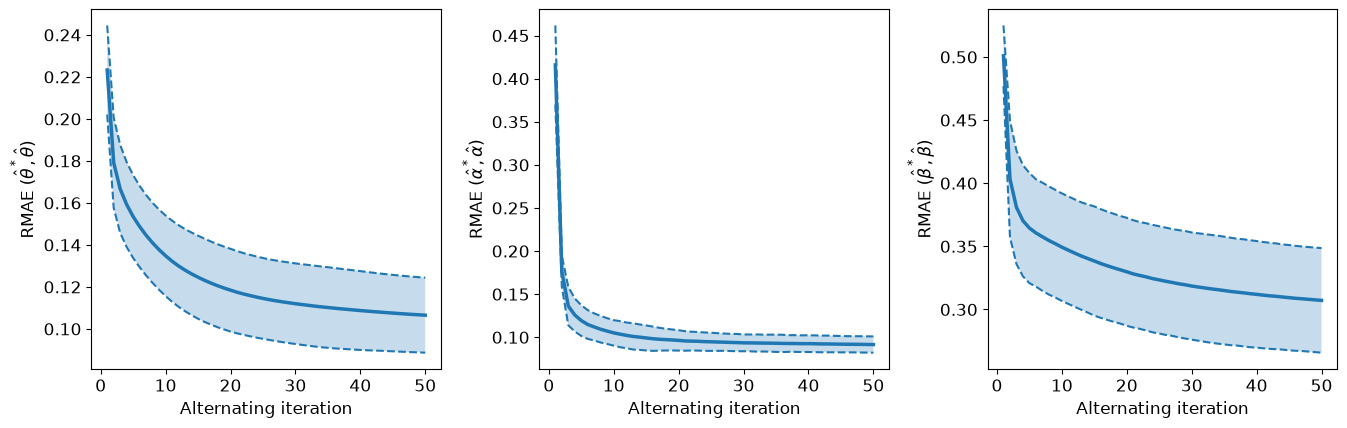

In [127]:
fig, axs = plt.subplots(1, 3, figsize=(14, 5))
fig.tight_layout(pad=4.0)


plot_convergence(
    true_values=oracle_pred_weights,
    pred_values=np.stack(weight_histories_over_rs),
    ax=axs[0],
    ylab=r"RMAE ($\hat{\theta}^*\!\!\!, \hat{\theta}$)"
)

plot_convergence(
    true_values=oracle_pred_as,
    pred_values=np.stack(a_histories_over_rs),
    ax=axs[1],
    ylab=r"RMAE ($\hat{\alpha}^*\!\!\!, \hat{\alpha}$)"
)

plot_convergence(
    true_values=oracle_pred_bs,
    pred_values=np.stack(b_histories_over_rs),
    ax=axs[2],
    ylab=r"RMAE ($\hat{\beta}^*\!\!\!, \hat{\beta}$)"
)

plt.show()

## Statistical properties of joint estimator

In [8]:
a, b = 2, 3
test_ratio = 0.25

param_name_2_true_value = {"a": a, "b": b}
param_name_2_axis_name = {"a": r'$\hat{\alpha}_v$', "b": r'$\hat{\beta}_v$'}
threshold_generator = beta(a, b)

gltm = LTM(g, threshold_generator=threshold_generator, random_state=random_state)
traces = gltm.sample_traces(n_traces, seed_size_range=seed_size_range)

train_traces, test_traces = trace_train_test_split(traces, test_ratio=test_ratio)

In [10]:
gltm_estim_ab = GLTWeightDistribEstimator(g, distrib_family=beta,
                                          distrib_params_2_range={"a": (1, 5), "b": (1, 5)})
gltm_estim_ab.fit(train_traces, max_alternate_iter=max_alternate_iter, tol=tol)                                     

In [11]:
vertex_2_indeg = dict(zip(g.get_vertices(), g.get_all_indegrees()))
vertex_2_train_size, vertex_2_n_inform_traces = compute_vertex_sample_size(train_traces)

In [12]:
vertex_2_nll_improvement_ratio = {v: gltm_estim_ab.nll_history_[v][-1] / gltm_estim_ab.nll_history_[v][0]
                            for v in gltm_estim_ab.informative_vertices}
vertex_2_nll_improvement = {v: gltm_estim_ab.nll_history_[v][0] - gltm_estim_ab.nll_history_[v][-1]
                            for v in gltm_estim_ab.informative_vertices}
vertex_2_nll_final = {v: gltm_estim_ab.nll_history_[v][-1] for v in gltm_estim_ab.informative_vertices}




In [13]:


def report_individual_node_results(
    node_sample,
    fitted_estim: GLTWeightDistribEstimator,
    fontsize=12,
    figsize=None,
    weight_error_metric=RMAE,
    metric_name="Relative MAE",
    colormap="turbo",
):
    from matplotlib import colormaps
    from matplotlib.ticker import MaxNLocator

    node_sample = list(node_sample)
    n_nodes = len(node_sample)
    n_params = len(fitted_estim.distrib_param_names)
    n_axes = 1 + n_params

    if n_nodes == 0:
        raise ValueError("node_sample must contain at least one node.")

    if figsize is None:
        figsize = (5.2 * n_axes, 5.5)

    fig, axs = plt.subplots(
        1,
        n_axes,
        figsize=figsize,
        squeeze=False,
        constrained_layout=True,
    )
    axs = axs.ravel()

    graph = fitted_estim.graph

    # Evenly sample a continuous colormap so colors do not repeat.
    cmap = colormaps[colormap]
    color_positions = np.linspace(0.03, 0.97, n_nodes)
    node_colors = {
        vertex: cmap(position)
        for vertex, position in zip(node_sample, color_positions)
    }

    line_width = 2.0 if n_nodes <= 15 else 1.6
    line_alpha = 0.95 if n_nodes <= 15 else 0.85

    def style_axis(ax):
        ax.set_facecolor("#fafafa")
        ax.grid(
            True,
            linestyle="--",
            linewidth=0.7,
            alpha=0.35,
        )
        ax.set_axisbelow(True)
        ax.tick_params(axis="both", labelsize=fontsize - 1)
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_alpha(0.5)
        ax.spines["bottom"].set_alpha(0.5)

    # Weight-estimation errors.
    error_ax = axs[0]

    for vertex in node_sample:
        parent_weights = graph.weights[
            graph.get_parents_mask(vertex)
        ]

        weight_errs = [
            weight_error_metric(parent_weights, predicted_weights)
            for predicted_weights
            in fitted_estim.weights_history_[vertex]
        ]

        iterations = np.arange(1, len(weight_errs) + 1)

        error_ax.plot(
            iterations,
            weight_errs,
            color=node_colors[vertex],
            linewidth=line_width,
            alpha=line_alpha,
        )

    error_ax.set_ylabel(
        rf"{metric_name} ($\hat{{\theta}}_v$)",
        fontsize=fontsize,
    )
    error_ax.set_xlabel(
        "Alternating Iteration",
        fontsize=fontsize,
    )
    style_axis(error_ax)

    # Distribution-parameter histories.
    for param_index, param_name in enumerate(
        fitted_estim.distrib_param_names
    ):
        ax = axs[param_index + 1]

        for vertex in node_sample:
            parameter_history = np.asarray(
                fitted_estim.distrib_param_history_[vertex]
            )

            values = parameter_history[:, param_index]
            iterations = np.arange(1, len(values) + 1)

            ax.plot(
                iterations,
                values,
                color=node_colors[vertex],
                linewidth=line_width,
                alpha=line_alpha,
            )

        ax.axhline(
            param_name_2_true_value[param_name],
            color="black",
            linestyle=(0, (5, 4)),
            linewidth=1.8,
            alpha=0.8,
            zorder=1,
            label="True value"
        )

        ax.set_ylabel(param_name_2_axis_name[param_name], fontsize=fontsize)
        ax.set_xlabel(
            "Alternating Iteration",
            fontsize=fontsize,
        )
        style_axis(ax)
        ax.legend(fontsize=fontsize, loc="lower right")

    return fig, axs


Sample size: 13


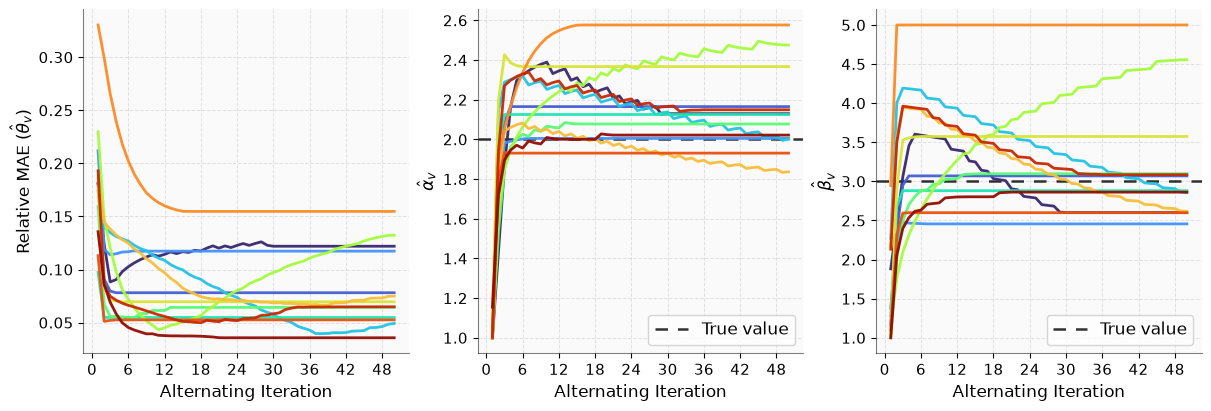

In [14]:
filter_cond = lambda v: (g.get_indegree(v) > 4  and 
                         gltm_estim_ab.nll_history_[v][-1] / gltm_estim_ab.nll_history_[v][0] < 0.95)
node_sample = [v for v in gltm_estim_ab.informative_vertices if filter_cond(v)]
print("Sample size:", len(node_sample))

report_individual_node_results(node_sample, gltm_estim_ab, figsize=(12, 4), 
                               weight_error_metric=RMAE, metric_name="Relative MAE")
plt.show()

In [15]:
def report_average_node_results(
    node_sample,
    fitted_estim: GLTWeightDistribEstimator,
    fontsize=12,
    figsize=None,
    weight_error_metric=RMAE,
    metric_name="Relative MAE",
    n_std=1.0,
    plot_train_nll=False,
    mean_color="tab:blue",
    fill_alpha=0.2,
):
    """
    Plot average convergence trends across nodes.

    Each panel shows:
        - the node-wise mean as a solid line,
        - mean ± n_std * std as dashed bounding lines,
        - the area between the bounds as a shaded region.

    Weight convergence is always plotted first. Train NLL convergence can
    optionally be plotted as the final panel.

    Parameters
    ----------
    node_sample
        Iterable of nodes included in the aggregation.

    fitted_estim
        Fitted GLTWeightDistribEstimator instance.

    fontsize
        Base font size for labels and ticks.

    figsize
        Figure size. If None, it is determined from the number of panels.

    weight_error_metric
        Function comparing true and estimated parent weights.

    metric_name
        Display name of the weight-error metric.

    n_std
        Number of standard deviations used for the bounds.

    plot_train_nll
        Whether to add a final Train NLL convergence panel using
        fitted_estim.nll_history_.

    mean_color
        Color used for the mean, bounds, and shaded region.

    fill_alpha
        Opacity of the shaded standard-deviation region.

    Returns
    -------
    fig, axs
        Matplotlib figure and one-dimensional array of axes.
    """
    from matplotlib.ticker import MaxNLocator

    node_sample = list(node_sample)
    n_nodes = len(node_sample)
    n_params = len(fitted_estim.distrib_param_names)

    # Weights are always plotted.
    n_axes = 1 + n_params + int(plot_train_nll)

    if n_nodes == 0:
        raise ValueError("node_sample must contain at least one node.")

    if n_std < 0:
        raise ValueError("n_std must be non-negative.")

    if figsize is None:
        figsize = (5.2 * n_axes, 5.5)

    fig, axs = plt.subplots(
        1,
        n_axes,
        figsize=figsize,
        squeeze=False,
        constrained_layout=True,
    )
    axs = axs.ravel()

    graph = fitted_estim.graph

    def style_axis(ax):
        ax.set_facecolor("#fafafa")
        ax.grid(
            True,
            linestyle="--",
            linewidth=0.7,
            alpha=0.35,
        )
        ax.set_axisbelow(True)
        ax.tick_params(
            axis="both",
            labelsize=max(fontsize - 1, 1),
        )
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_alpha(0.5)
        ax.spines["bottom"].set_alpha(0.5)

    def pad_histories(histories):
        """
        Pad histories with NaN so histories of different lengths can be
        aggregated iteration by iteration.
        """
        if not histories:
            raise ValueError("At least one history is required.")

        histories = [
            np.asarray(history, dtype=float).reshape(-1)
            for history in histories
        ]

        max_length = max(len(history) for history in histories)

        if max_length == 0:
            raise ValueError("Histories must contain at least one value.")

        padded = np.full(
            (len(histories), max_length),
            np.nan,
            dtype=float,
        )

        for row_index, history in enumerate(histories):
            padded[row_index, :len(history)] = history

        return padded

    def calculate_mean_and_bounds(
        histories,
        crop_lower_at_zero=False,
    ):
        values = pad_histories(histories)

        mean = np.nanmean(values, axis=0)
        std = np.nanstd(values, axis=0)

        lower = mean - n_std * std
        upper = mean + n_std * std

        if crop_lower_at_zero:
            lower = np.maximum(lower, 0.0)

        return mean, lower, upper

    def plot_mean_with_band(
        ax,
        histories,
        crop_lower_at_zero=False,
    ):
        """
        Plot the mean and standard-deviation band.

        Returns
        -------
        iterations
            The exact x coordinates used by the mean and filled region.
        """
        mean, lower, upper = calculate_mean_and_bounds(
            histories,
            crop_lower_at_zero=crop_lower_at_zero,
        )

        iterations = np.arange(1, len(mean) + 1)

        ax.fill_between(
            iterations,
            lower,
            upper,
            color=mean_color,
            alpha=fill_alpha,
            linewidth=0,
            zorder=1,
        )

        ax.plot(
            iterations,
            lower,
            color=mean_color,
            linestyle="--",
            linewidth=1.2,
            alpha=0.75,
            zorder=2,
        )

        ax.plot(
            iterations,
            upper,
            color=mean_color,
            linestyle="--",
            linewidth=1.2,
            alpha=0.75,
            zorder=2,
        )

        ax.plot(
            iterations,
            mean,
            color=mean_color,
            linewidth=2.5,
            zorder=3,
        )

        return iterations

    # ---------------------------------------------------------------
    # Weight-estimation error
    # ---------------------------------------------------------------
    weight_error_histories = []

    for vertex in node_sample:
        parent_weights = graph.weights[
            graph.get_parents_mask(vertex)
        ]

        weight_errors = [
            weight_error_metric(
                parent_weights,
                predicted_weights,
            )
            for predicted_weights
            in fitted_estim.weights_history_[vertex]
        ]

        weight_error_histories.append(weight_errors)

    error_ax = axs[0]

    plot_mean_with_band(
        error_ax,
        weight_error_histories,
        crop_lower_at_zero=True,
    )

    error_ax.set_ylabel(
        rf"{metric_name} ($\hat{{\theta}}_v$)",
        fontsize=fontsize,
    )
    error_ax.set_xlabel(
        "Alternating Iteration",
        fontsize=fontsize,
    )
    error_ax.set_ylim(bottom=0)
    style_axis(error_ax)

    # ---------------------------------------------------------------
    # Distribution-parameter histories
    # ---------------------------------------------------------------
    for param_index, param_name in enumerate(
        fitted_estim.distrib_param_names
    ):
        ax = axs[1 + param_index]
        parameter_histories = []

        for vertex in node_sample:
            vertex_history = np.asarray(
                fitted_estim.distrib_param_history_[vertex],
                dtype=float,
            )

            if vertex_history.ndim != 2:
                raise ValueError(
                    "Expected distrib_param_history_ for vertex "
                    f"{vertex} to be two-dimensional, but received "
                    f"shape {vertex_history.shape}."
                )

            if param_index >= vertex_history.shape[1]:
                raise ValueError(
                    f"Parameter index {param_index} is unavailable for "
                    f"vertex {vertex}; history shape is "
                    f"{vertex_history.shape}."
                )

            parameter_histories.append(
                vertex_history[:, param_index]
            )

        iterations = plot_mean_with_band(
            ax,
            parameter_histories,
            crop_lower_at_zero=False,
        )

        true_value = param_name_2_true_value[param_name]

        # Use the exact same x coordinates as the filled region.
        ax.plot(
            iterations,
            np.full(
                iterations.shape,
                true_value,
                dtype=float,
            ),
            color="black",
            linestyle=(0, (5, 4)),
            linewidth=1.8,
            alpha=0.8,
            zorder=4,
            label="True value",
        )

        ax.set_ylabel(
            param_name_2_axis_name[param_name],
            fontsize=fontsize,
        )
        ax.set_xlabel(
            "Alternating Iteration",
            fontsize=fontsize,
        )

        style_axis(ax)
        ax.legend(
            fontsize=fontsize,
            frameon=False,
        )

    # ---------------------------------------------------------------
    # Optional Train NLL panel
    # ---------------------------------------------------------------
    if plot_train_nll:
        if not hasattr(fitted_estim, "nll_history_"):
            raise AttributeError(
                "plot_train_nll=True, but fitted_estim does not have "
                "an nll_history_ attribute."
            )

        nll_histories = []

        for vertex in node_sample:
            try:
                vertex_nll_history = fitted_estim.nll_history_[vertex]
            except (KeyError, TypeError) as exc:
                raise ValueError(
                    "Expected fitted_estim.nll_history_ to contain a "
                    f"history for vertex {vertex}."
                ) from exc

            nll_histories.append(vertex_nll_history)

        nll_ax = axs[-1]

        plot_mean_with_band(
            nll_ax,
            nll_histories,
            crop_lower_at_zero=False,
        )

        nll_ax.set_ylabel(
            "Train NLL",
            fontsize=fontsize,
        )
        nll_ax.set_xlabel(
            "Alternating Iteration",
            fontsize=fontsize,
        )
        style_axis(nll_ax)

    return fig, axs

In [17]:
import pandas as pd 

info_table = pd.DataFrame(index=list(gltm_estim_ab.informative_vertices))
info_table["indegree"] = [vertex_2_indeg[v] for v in info_table.index]
info_table["train_size"] = [vertex_2_train_size[v] for v in info_table.index]
info_table["n_inform_traces"] = [vertex_2_n_inform_traces[v] for v in info_table.index]
info_table["nll_improvement"] = [vertex_2_nll_improvement[v] for v in info_table.index]
info_table["nll_final"] = [vertex_2_nll_final[v] for v in info_table.index]

In [18]:
info_table.corr().round(2)

,indegree,train_size,n_inform_traces,nll_improvement,nll_final
indegree,1.00,0.75,0.62,0.18,0.50
train_size,0.75,1.00,0.95,0.27,0.65
n_inform_traces,0.62,0.95,1.00,0.32,0.65
nll_improvement,0.18,0.27,0.32,1.00,0.42
nll_final,0.50,0.65,0.65,0.42,1.00


Sample size: 39


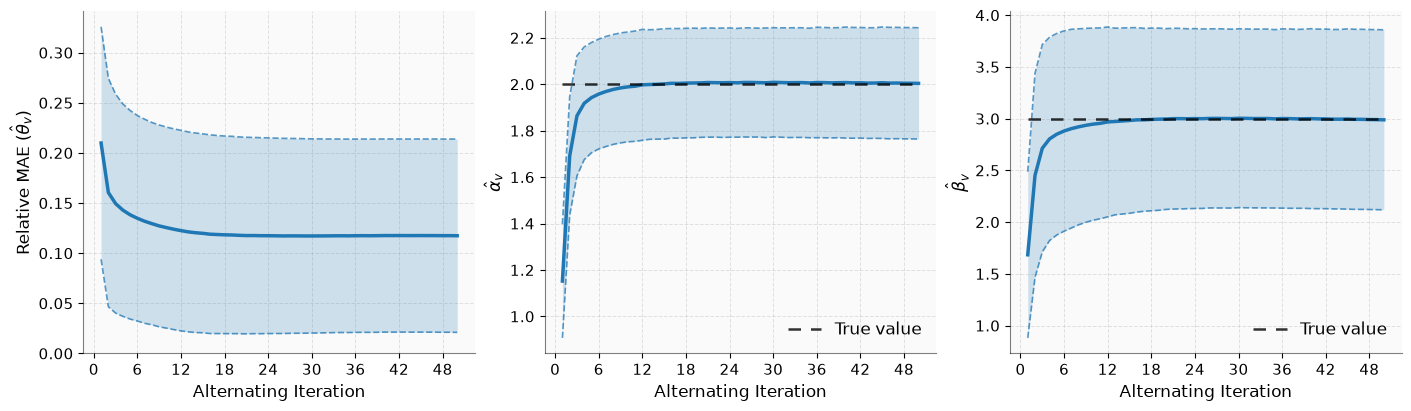

In [19]:

filter_cond =  lambda v: g.get_indegree(v) > 4 and \
    vertex_2_n_inform_traces[v] >= np.quantile(list(vertex_2_n_inform_traces.values()), q=0.5) 
node_sample = [v for v in gltm_estim_ab.informative_vertices if filter_cond(v)]
print("Sample size:", len(node_sample))

report_average_node_results(fitted_estim=gltm_estim_ab, node_sample=node_sample, n_std=1, figsize=(14, 4))
plt.show()